In [1]:
### Prediction using Elastic Net, Random Forest, Gradient Boosting

# pip install pandas numpy seaborn matplotlib scikit-learn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train.csv", index_col=0)

In [3]:
df.head()

,surface_area,agricultural_land,forest_area,armed_forces_total,urban_pop_major_cities,urban_pop_minor_cities,national_income,inflation_annual,inflation_monthly,inflation_weekly,mobile_subscriptions,internet_users,secure_internet_servers_total,improved_sanitation,women_parliament_seats_rate,life_expectancy
0,120540.0,2.632839e+06,5.417843e+06,1379000.0,55.747169,4.688831,unknown,NaN,NaN,NaN,less than 1 per person,0 per 1000 people,NaN,high access,[0%-25%),69.494195
1,752610.0,2.403039e+07,4.957554e+07,16500.0,16.890687,23.136313,very low,NaN,0.581473,NaN,less than 1 per person,154 per 1000 people,2.623624e+06,low access,[0%-25%),59.237366
2,1396.0,3.000000e+03,8.000000e+01,NaN,18.390090,23.139910,unknown,NaN,NaN,NaN,more than 1 per person,90 per 100 people,1.656589e+09,no info,unknown,81.300000
3,2758812.0,1.228845e+08,1.050943e+08,1518650.0,50.966885,24.522427,high,1.374906,NaN,NaN,more than 1 per person,76 per 100 people,6.625072e+08,very high access,[25%-50%),81.373197
4,340.0,1.100000e+04,1.699000e+04,NaN,5.311885,30.271115,unknown,-0.044229,NaN,NaN,more than 1 per person,350 per 1000 people,2.832808e+07,very high access,[25%-50%),73.193561


In [4]:
df.shape

# 16 columns
# Life expectancy is the dependent variable

(362, 16)

In [5]:
df.dtypes

surface_area                     float64
agricultural_land                float64
forest_area                      float64
armed_forces_total               float64
urban_pop_major_cities           float64
urban_pop_minor_cities           float64
national_income                      str
inflation_annual                 float64
inflation_monthly                float64
inflation_weekly                 float64
mobile_subscriptions                 str
internet_users                       str
secure_internet_servers_total    float64
improved_sanitation                  str
women_parliament_seats_rate          str
life_expectancy                  float64
dtype: object

In [6]:
df.describe()

,surface_area,agricultural_land,forest_area,armed_forces_total,urban_pop_major_cities,urban_pop_minor_cities,inflation_annual,inflation_monthly,inflation_weekly,secure_internet_servers_total,life_expectancy
count,3.620000e+02,3.580000e+02,3.570000e+02,3.180000e+02,360.000000,360.000000,146.000000,156.000000,20.000000,3.520000e+02,362.000000
mean,4.021884e+06,1.594881e+08,1.204151e+08,9.849864e+05,27.659456,29.175242,1.681539,0.475969,0.396478,2.949654e+08,71.059691
std,1.234491e+07,4.964143e+08,3.796623e+08,2.994686e+06,20.512885,21.206494,0.980308,0.153430,0.203583,7.234006e+08,8.332818
min,3.030000e+01,3.000000e+02,0.000000e+00,5.000000e+01,0.091444,0.074575,-2.372263,0.250543,0.209993,4.002500e+04,48.850634
25%,2.783000e+04,1.054198e+06,4.951445e+05,1.218000e+04,10.624625,11.013743,1.202953,0.347799,0.232118,3.468446e+06,65.469854
50%,2.037745e+05,5.360256e+06,3.928535e+06,5.352500e+04,24.459439,26.735127,1.762683,0.459790,0.297938,2.671228e+07,73.238024
75%,1.081610e+06,4.221935e+07,2.241297e+07,2.598000e+05,38.587177,43.499418,2.485675,0.577340,0.537541,2.173937e+08,77.125610
max,1.343253e+08,5.067600e+09,4.132117e+09,2.720662e+07,92.409069,89.142904,2.997694,0.810152,0.781527,8.207343e+09,83.480488


In [7]:
# Check missing values

df.isnull().sum()

surface_area                       0
agricultural_land                  4
forest_area                        5
armed_forces_total                44
urban_pop_major_cities             2
urban_pop_minor_cities             2
national_income                    0
inflation_annual                 216
inflation_monthly                206
inflation_weekly                 342
mobile_subscriptions               0
internet_users                     0
secure_internet_servers_total     10
improved_sanitation                0
women_parliament_seats_rate        0
life_expectancy                    0
dtype: int64

In [8]:
df1 = df.copy()

# Inflation has the most number of missing values

# Using weekly inflation to fill in values for monthly inflation
# Using monthly inflation to fill in annual inflation series

for i in df1.index:
    if np.isnan(df1.loc[i,'inflation_annual']):
        if np.isnan(df1.loc[i,'inflation_monthly']):
            df1.loc[i,'inflation_annual'] = ((1 + df1.loc[i, 'inflation_weekly']/100)**52 - 1) * 100
        else:
            df1.loc[i,'inflation_annual'] = ((1 + df1.loc[i, 'inflation_monthly']/100)**12 - 1) * 100

# Remove columns inflation_weekly and inflation_monthly

df1.drop(['inflation_weekly','inflation_monthly'], axis=1, inplace=True)

In [9]:
df1.isnull().sum()

surface_area                      0
agricultural_land                 4
forest_area                       5
armed_forces_total               44
urban_pop_major_cities            2
urban_pop_minor_cities            2
national_income                   0
inflation_annual                 40
mobile_subscriptions              0
internet_users                    0
secure_internet_servers_total    10
improved_sanitation               0
women_parliament_seats_rate       0
life_expectancy                   0
dtype: int64

In [10]:
# Check the frequency of categories (labels) in each categorical variable 

for name in df1.select_dtypes(include=['str']):
    print(name,':')
    print(df1[name].value_counts(),'\n')

national_income :
national_income
low            81
very low       77
medium low     76
unknown        48
high           37
medium high    31
very high      12
Name: count, dtype: int64 

mobile_subscriptions :
mobile_subscriptions
more than 1 per person    188
less than 1 per person    164
unknown                     7
more than 2 per person      2
more than 3 per person      1
Name: count, dtype: int64 

internet_users :
internet_users
41 per 100 people      8
60 per 100 people      7
46 per 100 people      7
unknown                6
90 per 100 people      5
                      ..
392 per 1000 people    1
131 per 1000 people    1
15 per 1000 people     1
138 per 1000 people    1
374 per 1000 people    1
Name: count, Length: 198, dtype: int64 

improved_sanitation :
improved_sanitation
very high access    155
low access           55
medium access        54
high access          47
very low access      33
no info              18
Name: count, dtype: int64 

women_parliament_seats_rate 

In [11]:
# For Random forests, we need to assign numerical values to the categorical variables

# The variable 'national_income' has a natural order, so ordinal encoding can be used

mapper_1 = {'very low': 0,
            'low': 1,
            'medium low': 3,
            'medium high': 4,
            'high': 5,
            'very high': 6}

# Create a dummy that assigns 1 to unknown and 0 otherwise

df1['national_income_unknown'] = df1['national_income'].eq('unknown').astype('int')

df1['national_income'] = df1['national_income'].replace(mapper_1)

# Unknown values are replaced with NaN

df1['national_income'] = df1['national_income'].replace('unknown', np.nan)

In [12]:
# The variable 'mobile_subscriptions' has a natural order too, so ordinal encoding can be used

mapper_2 = {'less than 1 per person': 0,
            'more than 1 per person': 1,
            'more than 2 per person': 2,
            'more than 3 per person': 3}

# Create a dummy that assigns 1 to unknown and 0 otherwise

df1['mobile_subscriptions_unknown'] = df1['mobile_subscriptions'].eq('unknown').astype('int')

df1['mobile_subscriptions'] = df1['mobile_subscriptions'].replace(mapper_2)

# Unknown values are replaced with NaN

df1['mobile_subscriptions'] = df1['mobile_subscriptions'].replace('unknown', np.nan)

In [13]:
# The variable 'improved_sanitation' has a natural order too, so ordinal encoding can be used

mapper_3 = {'very low access': 0,
            'low access': 1,
            'medium access': 2,
            'high access': 3,
            'very high access': 4}

# Create a dummy that assigns 1 to unknown and 0 otherwise

df1['improved_sanitation_unknown'] = df1['improved_sanitation'].eq('no info').astype('int')

df1['improved_sanitation'] = df1['improved_sanitation'].replace(mapper_3)

df1['improved_sanitation'] = df1['improved_sanitation'].replace('no info', np.nan)

In [14]:
# The variable 'women_parliament_seats_rate' has a natural order too, so ordinal encoding can be used

mapper_4 = {'[0%-25%)': 0,
            '[25%-50%)': 1,
            '[50%-75%)': 2}

# Create a dummy that assigns 1 to unknown and 0 otherwise

df1['women_parliament_seats_rate_unknown'] = df1['women_parliament_seats_rate'].eq('unknown').astype('int')

df1['women_parliament_seats_rate'] = df1['women_parliament_seats_rate'].replace(mapper_4)

df1['women_parliament_seats_rate'] = df1['women_parliament_seats_rate'].replace('unknown', np.nan)

In [15]:
# Convert the variable 'internet_users' into percent

var_split = df1['internet_users'].str.split()
df1['percent_internet_users'] = (pd.to_numeric(var_split.str.get(0), errors='coerce')/
                                 pd.to_numeric(var_split.str.get(2), errors='coerce'))

df1.drop('internet_users', axis=1, inplace=True)

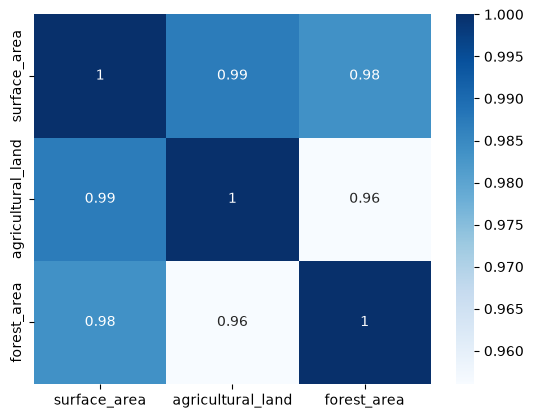

In [16]:
# Address multicollinearity

# The variables 'surface_area', 'agricultural_land' and 'forest_area' seem to be highly correlated

sns.heatmap(df1[['surface_area', 'agricultural_land', 'forest_area']].corr(),cmap='Blues',annot=True);

# Note: Random forest can handle correlated predictors. However, the model can split the importance amongst 
# the correlated predictors making each appear less important (the correlated variables may contain the same information)

In [17]:
# From the descriptive statistics, Surface area seems to be in km^2 whereas agricultural and forest land could be in hectares

df1['surface_area'] = df1['surface_area']*100
df1['agricultural_land_share'] = df1['agricultural_land']/df1['surface_area']
df1['forest_area_share'] = df1['forest_area']/df1['surface_area']

df1.drop(['agricultural_land', 'forest_area'], axis=1, inplace=True)

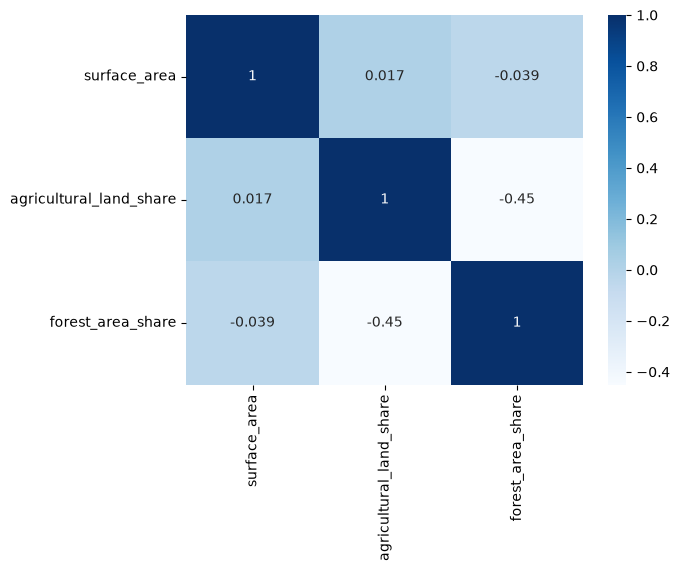

In [18]:
sns.heatmap(df1[['surface_area', 'agricultural_land_share', 'forest_area_share']].corr(),cmap='Blues',annot=True);

In [19]:
# Missing data
# Median is the safer default given the presence of outliers

df2 = df1.copy()

from sklearn.impute import SimpleImputer

med = SimpleImputer(strategy='median')
med.fit(df2)
df2 = pd.DataFrame(data=med.transform(df2), columns = df2.columns)

#df2.isnull().sum()

In [20]:
# Test data

dft = pd.read_csv("test.csv", index_col=0)
dft.isnull().sum()
dft1 = dft.copy()

# Inflation has the most number of missing values

for i in dft1.index:
    if np.isnan(dft1.loc[i,'inflation_annual']):
        if np.isnan(dft1.loc[i,'inflation_monthly']):
            dft1.loc[i,'inflation_annual'] = ((1 + dft1.loc[i, 'inflation_weekly']/100)**52 - 1) * 100
        else:
            dft1.loc[i,'inflation_annual'] = ((1 + dft1.loc[i, 'inflation_monthly']/100)**12 - 1) * 100

# Remove columns inflation_weekly and inflation_monthly

dft1.drop(['inflation_weekly','inflation_monthly'], axis=1, inplace=True)

# Converting catergorical variable 'national_income' into numeric

dft1['national_income_unknown'] = dft1['national_income'].eq('unknown').astype('int')
dft1['national_income'] = dft1['national_income'].replace(mapper_1)
dft1['national_income'] = dft1['national_income'].replace('unknown', np.nan)

# Converting catergorical variable 'mobile_subscriptions' into numeric

dft1['mobile_subscriptions_unknown'] = dft1['mobile_subscriptions'].eq('unknown').astype('int')
dft1['mobile_subscriptions'] = dft1['mobile_subscriptions'].replace(mapper_2)
dft1['mobile_subscriptions'] = dft1['mobile_subscriptions'].replace('unknown', np.nan)

# Converting catergorical variable 'improved_sanitation' into numeric

dft1['improved_sanitation_unknown'] = dft1['improved_sanitation'].eq('no info').astype('int')
dft1['improved_sanitation'] = dft1['improved_sanitation'].replace(mapper_3)
dft1['improved_sanitation'] = dft1['improved_sanitation'].replace('no info', np.nan)

# Converting catergorical variable 'women_parliament_seats_rate' into numeric

dft1['women_parliament_seats_rate_unknown'] = dft1['women_parliament_seats_rate'].eq('unknown').astype('int')
dft1['women_parliament_seats_rate'] = dft1['women_parliament_seats_rate'].replace(mapper_4)
dft1['women_parliament_seats_rate'] = dft1['women_parliament_seats_rate'].replace('unknown', np.nan)

# Convert the variable 'internet_users' into percent

var_split1 = dft1['internet_users'].str.split()
dft1['percent_internet_users'] = (pd.to_numeric(var_split1.str.get(0), errors='coerce')/
                                 pd.to_numeric(var_split1.str.get(2), errors='coerce'))

dft1.drop('internet_users', axis=1, inplace=True)

# Address multicollinearity

dft1['surface_area'] = dft1['surface_area']*100
dft1['agricultural_land_share'] = dft1['agricultural_land']/dft1['surface_area']
dft1['forest_area_share'] = dft1['forest_area']/dft1['surface_area']

dft1.drop(['agricultural_land', 'forest_area'], axis=1, inplace=True)

# Missing data

dft2 = dft1.copy()
med.fit(dft2)
dft2 = pd.DataFrame(data=med.transform(dft2), columns = dft2.columns)

In [21]:
# Elastic Net

from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=33
)

# X and y

y = df2['life_expectancy']
X = df2.drop('life_expectancy', axis=1)

# Pipeline: standardize variables, then estimate Elastic Net

elastic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=10000))
])

# Hyperparameters

param_grid_en = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10],
    'model__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9]
}

# Set up Grid Search

grid_elastic = GridSearchCV(
    estimator=elastic,
    param_grid=param_grid_en,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Run Grid Search

grid_elastic.fit(X, y)

# Print hyperparameters

print("Best parameters:")
print(grid_elastic.best_params_)

# Best MAE

print("Best CV MAE:")
print(-grid_elastic.best_score_)

# Best Elastic Net model

best_elastic = grid_elastic.best_estimator_

print(best_elastic)

Best parameters:
{'model__alpha': 0.1, 'model__l1_ratio': 0.75}
Best CV MAE:
2.9573600820691524
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 ElasticNet(alpha=0.1, l1_ratio=0.75, max_iter=10000))])


In [22]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=33)

# Hyperparameters

param_grid_rf = {
    'n_estimators': [50, 100, 150, 200],             # no of trees
    'max_features': [3, 4, 6, 8, 10, 13, 18],        # max no of predictor variables to be considered at each split
    'max_depth': [5, 6, 7],                          # max tree depth
    'min_samples_split': [2, 3, 4],                  # min no of observations required before a node can be split
    'min_samples_leaf': [1, 2, 3]                    # min observations that must remain in each terminal leaf
}

# Set up Grid Search

grid = GridSearchCV(
    estimator = rf,
    param_grid = param_grid_rf,
    cv = cv,
    scoring = 'neg_mean_absolute_error',
    n_jobs = -1
)

# Run the Grid Search

grid.fit(X, y)

# Print hyperparameters

print("Best parameters:")
print(grid.best_params_)

# Best MAE

print("Best CV MAE:")
print(-grid.best_score_)

# Best Random Forest model

best_rf = grid.best_estimator_

print(best_rf)

Best parameters:
{'max_depth': 7, 'max_features': 13, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 50}
Best CV MAE:
2.4570467567968857
RandomForestRegressor(max_depth=7, max_features=13, min_samples_split=3,
                      n_estimators=50, random_state=33)


In [23]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

gbm = GradientBoostingRegressor(random_state=33)

param_grid_gbm = {
    'n_estimators': [50, 100, 150, 200],        # no of sequential trees
    'learning_rate': [0.01, 0.05, 0.1],         # contribution of each new tree
    'max_depth': [2, 3, 4],                     # max depth of each individual tree
    'min_samples_split': [2, 5, 10],            # min observations required before a node can split
    'min_samples_leaf': [1, 2, 5]               # min observations that must remain in a terminal leaf
}

# Set up Grid Search

grid_gbm = GridSearchCV(
    estimator=gbm,
    param_grid=param_grid_gbm,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Run the Grid Search

grid_gbm.fit(X, y)

# Print hyperparameters

print("Best parameters:")
print(grid_gbm.best_params_)

# Best MAE

print("Best CV MAE:")
print(-grid_gbm.best_score_)

# Best Gradient Boosting model

best_gbm = grid_gbm.best_estimator_

print(best_gbm)

Best parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV MAE:
2.1999450991769445
GradientBoostingRegressor(max_depth=4, min_samples_leaf=2, min_samples_split=5,
                          n_estimators=200, random_state=33)


In [24]:
from sklearn.model_selection import KFold, cross_val_score

# Elastic Net
elastic_scores = -cross_val_score(
    best_elastic,
    X,
    y,
    cv=cv,
    scoring='neg_mean_absolute_error'
)

# Random Forest
rf_scores = -cross_val_score(
    best_rf,
    X,
    y,
    cv=cv,
    scoring='neg_mean_absolute_error'
)

# Gradient Boosting
gbm_scores = -cross_val_score(
    best_gbm,
    X,
    y,
    cv=cv,
    scoring='neg_mean_absolute_error'
)

print("EN fold MAEs:", elastic_scores)
print("RF fold MAEs:", rf_scores)
print("GBM fold MAEs:", gbm_scores)

print("EN mean MAE:", np.mean(elastic_scores))
print("RF mean MAE:", np.mean(rf_scores))
print("GBM mean MAE:", np.mean(gbm_scores))

EN fold MAEs: [2.95495279 2.60300852 3.10026148 2.9309073  3.19767032]
RF fold MAEs: [2.44563236 2.20231838 2.40301024 2.23073106 3.00354175]
GBM fold MAEs: [2.27980938 1.91748037 2.15063365 1.92484097 2.72696112]
EN mean MAE: 2.9573600820691524
RF mean MAE: 2.4570467567968857
GBM mean MAE: 2.1999450991769445


In [25]:
# Get the out-of-fold predictions for each model

from sklearn.model_selection import cross_val_predict

# Out-of-fold predictions using the same 5-fold CV
elastic_pred = cross_val_predict(
    best_elastic,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

rf_pred = cross_val_predict(
    best_rf,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

gbm_pred = cross_val_predict(
    best_gbm,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

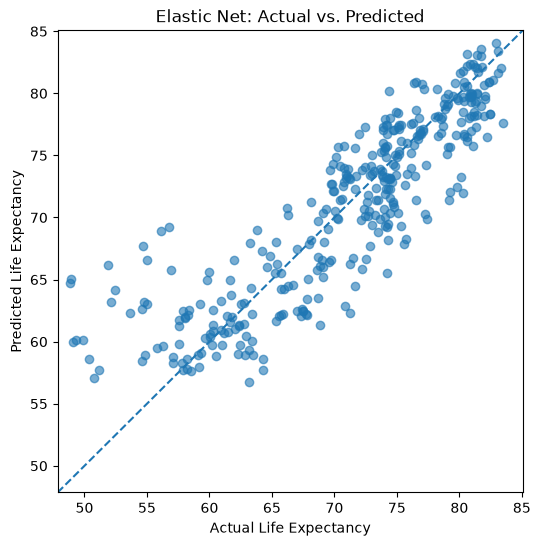

In [26]:
# Actual versus Predicted (Elastic Net)

plt.figure(figsize=(6, 6))

plt.scatter(y, elastic_pred, alpha=0.6)

min_val = min(y.min(), elastic_pred.min())
max_val = max(y.max(), elastic_pred.max())

padding = 1

lims = [min_val - padding, max_val + padding]

plt.plot(lims, lims, '--')

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Elastic Net: Actual vs. Predicted')

plt.savefig('en_actual_predicted.png',
            dpi=300, bbox_inches='tight')

plt.show()

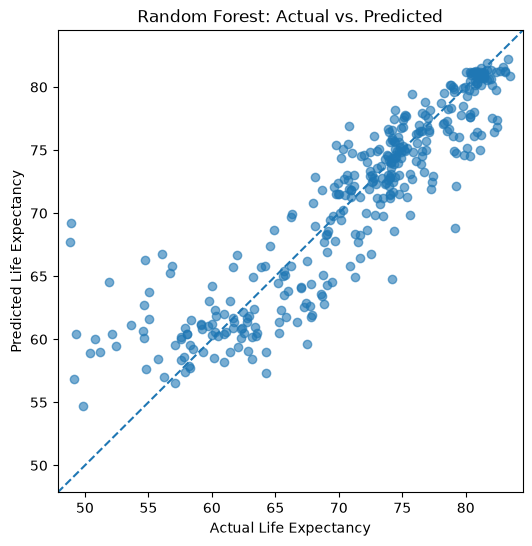

In [27]:
# Actual versus Predicted (Random Forest)

plt.figure(figsize=(6, 6))

plt.scatter(y, rf_pred, alpha=0.6)

min_val = min(y.min(), rf_pred.min())
max_val = max(y.max(), rf_pred.max())

padding = 1

lims = [min_val - padding, max_val + padding]

plt.plot(lims, lims, '--')

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Random Forest: Actual vs. Predicted')

plt.savefig('rf_actual_predicted.png',
            dpi=300, bbox_inches='tight')

plt.show()

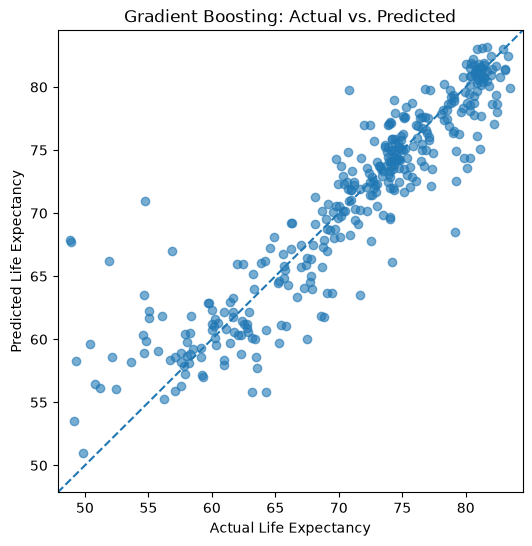

In [28]:
# Actual versus Predicted (Gradient Boosting)

plt.figure(figsize=(6, 6))

plt.scatter(y, gbm_pred, alpha=0.6)

min_val = min(y.min(), gbm_pred.min())
max_val = max(y.max(), gbm_pred.max())

padding = 1

lims = [min_val - padding, max_val + padding]

plt.plot(lims, lims, '--')

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Gradient Boosting: Actual vs. Predicted')

plt.savefig('gbm_actual_predicted.png',
            dpi=300, bbox_inches='tight')

plt.show()

In [29]:
# Histogram

def plot_histogram_comp(x, y, filename=None):
    plt.hist(x, alpha=0.5, edgecolor='black', label='Actual')
    plt.hist(y, alpha=0.5, edgecolor='black', label='Prediction')
    
    plt.title("Histogram of Actual vs. Predicted Outcomes")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.legend(loc='upper left')
    
    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()

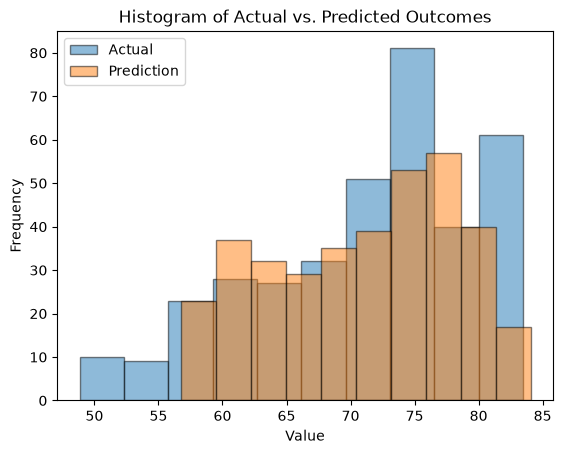

In [30]:
# Histogram (Elastic Net) using actual y and predicted y of train set

plot_histogram_comp(y,elastic_pred,filename='en_hist_train.png')

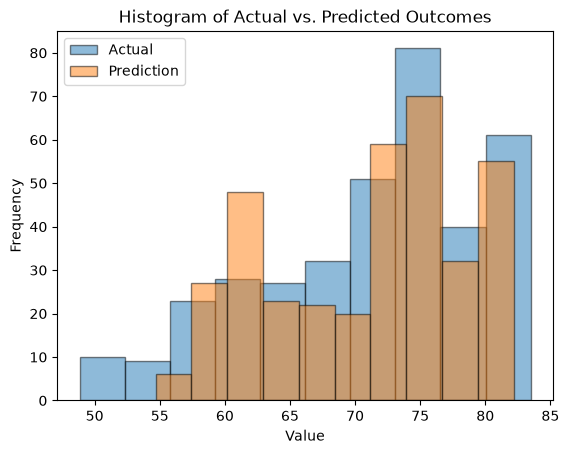

In [31]:
# Histogram (Random Forest) using actual y and predicted y of train set

plot_histogram_comp(y,rf_pred,filename='rf_hist_train.png')

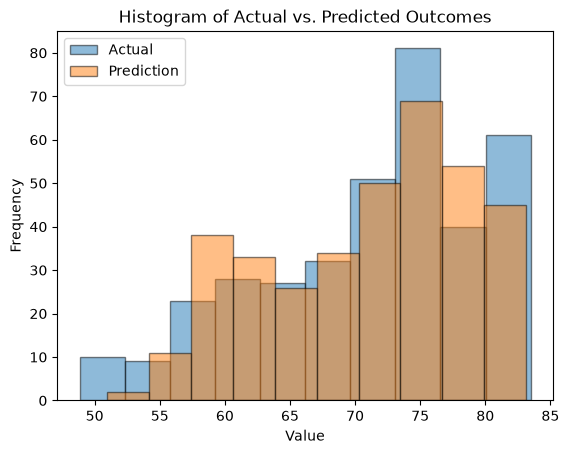

In [32]:
# Histogram (Gradient Boosting) using actual y and predicted y of train set

plot_histogram_comp(y,gbm_pred,filename='gbm_hist_train.png')

In [33]:
# Using the Gradient Boosting model to predict life expectancy for the test set

gbm_test_pred = best_gbm.predict(dft2)

predictions = pd.DataFrame(
    {'life_expectancy': gbm_test_pred},
    index=dft.index
)

predictions.to_csv('gbm_test_predictions.csv')

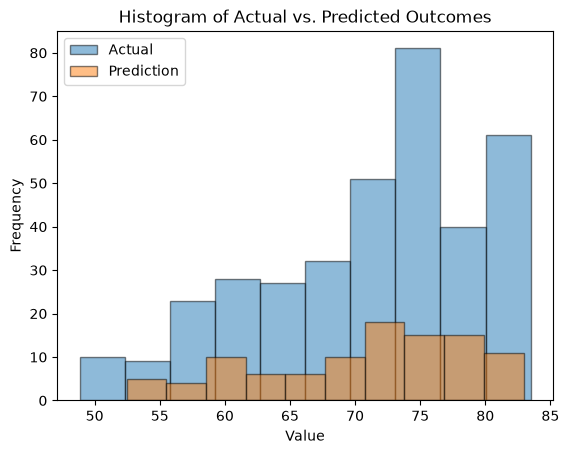

In [34]:
# Histogram of predicted life expectancy of test set as compared to that of actual life expectancy of train set

plot_histogram_comp(y,gbm_test_pred)

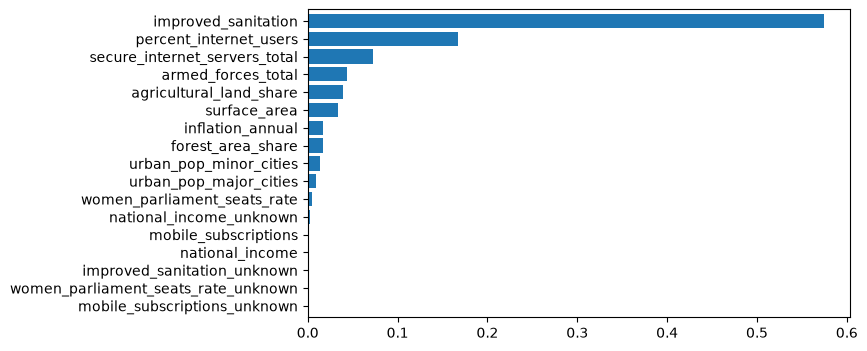

In [35]:
# Feature Importance for the Gradient Boosting model

feature_imp = pd.Series(best_gbm.feature_importances_, index=X.columns)
feature_imp.sort_values(ascending=True, inplace=True)

# Creating a bar plot
feature_imp.plot(kind='barh', width=0.8, figsize=(7,4));
plt.savefig('feat_imp', dpi=300, bbox_inches='tight')

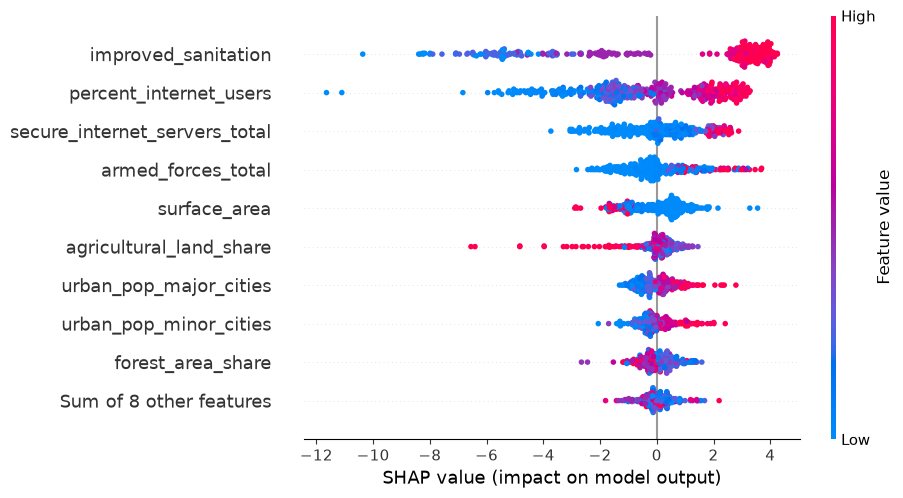

In [38]:
# Shapley values - how much each predictor contributes to prediction
# %pip install shap
import warnings
from tqdm import TqdmWarning

import shap

# Create SHAP explainer for the best GBM model
explainer = shap.Explainer(best_gbm)

# Calculate SHAP values for all observations
shap_values = explainer(X)

shap.plots.beeswarm(shap_values,show=False)
plt.savefig('shap_gbm', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
#df.groupby('national_income')['life_expectancy'].agg(['mean', 'count'])

#df1[['national_income', 'improved_sanitation', 'percent_internet_users']].corr()